# Post-Quantum Signature Performance Analysis

This Jupyter Notebook offers a comprehensive performance evaluation of various Post-Quantum Cryptography (**PQC**) digital signature mechanisms, with a particular focus on algorithms undergoing the NIST PQC standardization process. It precisely measures **key generation times, the crucial time taken for signing messages, and the time for verifying those signatures**. Additionally, the notebook quantifies the sizes of public keys, private keys, and signatures across different [**NIST security levels**](https://csrc.nist.rip/groups/ST/post-quantum-crypto/evaluation-criteria.html). All collected data, including key and signature sizes and their corresponding security levels which you can also reference from the [**liboqs**](https://openquantumsafe.org/liboqs/algorithms) documentation, are clearly presented in tables and charts. The primary objective is to assess the practical applicability of these forward-looking PQC algorithms based on their real-world performance characteristics.
![Signature Scheme](https://www.researchgate.net/profile/Ouail-Ouchetto/publication/358802566/figure/fig1/AS:1126646925017090@1645624967748/Public-key-digital-signature-scheme-Alice-uses-her-private-key-to-sign-her-messages-Bob.png)

## Table of Contents
- [Requirements](#requirements)
- [Code](#code)
- [Output](#output)
    - [Level 1](#l1)
    - [Level 2](#l2)
    - [Level 3](#l3)
- [Conclusion](#conclusion)

## Requirements <a id="requirements"></a>

In [1]:
import sys
!"{sys.executable}" -m pip install -q -r requirements.txt

In [2]:
# Requirements 
import oqs
import timeit
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Panda options
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Definitions
signature_L1 = ["ML-DSA-44",
                "Falcon-512", 
                "Falcon-padded-512", 
                "SPHINCS+-SHA2-128f-simple",
                "SPHINCS+-SHA2-128s-simple",
                "SPHINCS+-SHAKE-128f-simple",
                "SPHINCS+-SHAKE-128s-simple"
               ] 
               

signature_L3 = ["ML-DSA-65", 
                "SPHINCS+-SHA2-192f-simple",
                "SPHINCS+-SHA2-192s-simple",
                "SPHINCS+-SHAKE-192f-simple", 
                "SPHINCS+-SHAKE-192s-simple"]

signature_L5 = ["ML-DSA-87", 
                "Falcon-1024",
                "Falcon-padded-1024",
                "SPHINCS+-SHA2-256f-simple",
                "SPHINCS+-SHA2-256s-simple",
                "SPHINCS+-SHAKE-256f-simple", 
                "SPHINCS+-SHAKE-256s-simple"]

test_runs = 100
#test_runs = 10000 #size in KEM Notebook, takes to much time
message = "This is the message to sign"

**Notes on the Algorithms:**

It's important to note that **ML-DSA-44** is listed under Level 1, although it's actually assigned to NIST Level 2. For Falcon, there are two variants: [**Falcon**](https://github.com/PQClean/PQClean/issues/552) is with variable signature size and Falcon-padded with a fixed signature size. [**SPHINCS+**](https://nvlpubs.nist.gov/nistpubs/fips/nist.fips.205.pdf) variants (-f for fast, -s for small) offer optimizations for either performance or signature size. Similar to Falcon's approach with signature sizes, [**SPHINCS+SHAKE**](https://ssojet.com/compare-hashing-algorithms/sha-256-vs-shake256/#:~:text=The%20most%20prominent%20distinction%20is,the%20exact%20size%20they%20need.)   provides a variable hash size, contrasting with [**SPHINCS+SHA2**](https://ssojet.com/compare-hashing-algorithms/sha-256-vs-shake256/#:~:text=The%20most%20prominent%20distinction%20is,the%20exact%20size%20they%20need.), which employs a fixed hash size. It's crucial to understand that while both Falcon and SPHINCS+ have been selected for standardization, their current implementations within liboqs are based on the Round 3 submissions, not the finalized NIST standards drafts. For more comprehensive details, you can always refer to the [**liboqs GitHub page**](https://github.com/open-quantum-safe/liboqs)

## Code <a id="code"></a>

In [4]:
# Functions

def generate_keys(algorithm, security_level):
        signer = oqs.Signature(algorithm)
        public_key = signer.generate_keypair()
        secret_key = signer.export_secret_key()
        return { 'Algorithm': algorithm, 'Security Level': security_level,
            'Public Key (hex)': public_key.hex(), 'Public Key length': len(public_key),
            'Secret Key (hex)': secret_key.hex(), 'Secret Key length': len(secret_key)}, signer


def sign_message(algorithm, security_level, message, signer_instance):
        signature = signer_instance.sign(message.encode('utf-8'))
        return { 'Algorithm': algorithm, 'Security Level': security_level,
            'Message (plain)': message, 'Message length': len(message.encode('utf-8')),
            'Signature' : signature.hex(), 'Signature length' : len(signature)}, signature
    
def verify(algorithm, security_level, signature, message, public_key):
    verifier = oqs.Signature(algorithm)
    is_valid = verifier.verify(message.encode('utf-8'), signature, public_key)
    return { 'Algorithm': algorithm, 'Security Level': security_level, 'Is Valid' : is_valid}



def times_to_df(algorithm: str, execution_times: list, security_level: str, operation_type: str) -> pd.DataFrame:
    avg_time = sum(execution_times) / len(execution_times)
    min_time = min(execution_times)
    max_time = max(execution_times)

    data = {
        'Algorithm': [algorithm],
        'Security Level': [security_level],
        'Operation': [operation_type],
        'Min_Time (s)': [min_time], 
        'Average_Time (s)': [avg_time],
        'Max_Time (s)': [max_time] 
    }

    return pd.DataFrame(data)


def measure_execution_times(func, num_runs, *func_args):
    times = timeit.repeat(lambda: func(*func_args), number=1, repeat=num_runs)
    return times



def process_signing_level(algorithms_list: list, runs: int, level_name: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    keys_data_list = []
    key_times_list = []
    signing_data_list = []
    signing_times_list = []
    verify_data_list = []
    verify_times_list = []

    for alg in algorithms_list:
        keys_info, signer_instance = generate_keys(alg, level_name)
        keys_data_list.append(keys_info)

        times_keys = measure_execution_times(generate_keys, runs, alg, level_name)
        time_df_keys = times_to_df(alg, times_keys, level_name, "Key Generation")
        key_times_list.append(time_df_keys)
        public_key = bytes.fromhex(keys_info['Public Key (hex)']) 

        signing_data, signature = sign_message(alg, level_name, message, signer_instance)
        signing_data_list.append(signing_data)
        times_signing = measure_execution_times(sign_message, runs, alg, level_name, message, signer_instance)
        time_df_signing = times_to_df(alg, times_signing, level_name, "Signing")
        signing_times_list.append(time_df_signing)


        verify_data = verify(alg, level_name, signature, message, public_key)
        verify_data_list.append(verify_data)
        times_verify = measure_execution_times(verify, runs, alg, level_name, signature, message, public_key)
        time_df_verify = times_to_df(alg, times_verify, level_name, "Verify")
        verify_times_list.append(time_df_verify)

    df_keys = pd.DataFrame(keys_data_list)
    df_time_keys = pd.concat(key_times_list, ignore_index=True)
    df_signing = pd.DataFrame(signing_data_list)
    df_time_signing = pd.concat(signing_times_list, ignore_index=True)
    df_verify = pd.DataFrame(verify_data_list)
    df_time_verify = pd.concat(verify_times_list, ignore_index=True)


    return df_keys, df_time_keys, df_signing, df_time_signing, df_verify, df_time_verify 

In [5]:
# show Results

def display_results(level_name: str, df: pd.DataFrame, description: str):
    print(f"\n--- {description} ({level_name}) ---") 
    print(df)

def plot_key_length_comparison(df_keys_all: pd.DataFrame, plot_type: str = 'keys'):

    if plot_type == 'keys':
        value_vars_to_plot = ['Public Key length', 'Secret Key length']
        plot_title = 'Public and Secret Key Lengths in Bytes per Algorithm'
    elif plot_type == 'signature':
        value_vars_to_plot = ['Signature length']
        plot_title = 'Signature Lengths in Bytes per Algorithm'

    df_keys_all_melted = df_keys_all.melt(
        id_vars=['Algorithm', 'Security Level'],
        value_vars=value_vars_to_plot,
        var_name='Key Type',
        value_name='Length (Bytes)'
    )
    
    df_keys_all_melted_filtered = df_keys_all_melted[df_keys_all_melted['Length (Bytes)'] > 0].copy()

    level_order = ["L1", "L3", "L5", "Unknown"]

    df_keys_all_melted_filtered.loc[:, 'Security Level'] = pd.Categorical(
        df_keys_all_melted_filtered['Security Level'], categories=level_order, ordered=True)

    df_keys_all_melted_filtered = df_keys_all_melted_filtered.sort_values(['Security Level', 'Algorithm'])

    plt.figure(figsize=(15, 8))
    sns.barplot(
        data=df_keys_all_melted_filtered,
        x='Algorithm',
        y='Length (Bytes)',
        hue='Key Type' if plot_type == 'keys' else None
    )
    plt.title(plot_title)
    plt.xlabel('Algorithm')
    plt.ylabel('Length (Bytes)')
    plt.xticks(rotation=45, ha='right')
    if len(value_vars_to_plot) > 1:
        plt.legend(title='Key Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_timing_comparison(df_time_all: pd.DataFrame, runs: int, title_suffix: str, level: str): 
    print(f"\n--- Plot: {title_suffix} Times ---") 

    df_time_all_melted = df_time_all.melt(
        id_vars=['Algorithm', 'Security Level'],
        value_vars=['Min_Time (s)', 'Average_Time (s)', 'Max_Time (s)'],
        var_name='Time Metric',
        value_name='Time (s)' 
    )

    level_order = ["L1", "L3", "L5", "Unknown"]
    df_time_all_melted.loc[:, 'Security Level'] = pd.Categorical(
        df_time_all_melted['Security Level'], categories=level_order, ordered=True
    )
    df_time_all_melted = df_time_all_melted.sort_values(
        ['Security Level', 'Algorithm']
    )

    plt.figure(figsize=(15, 8))
    sns.barplot(
        data=df_time_all_melted,
        x='Algorithm',
        y='Time (s)', 
        hue='Time Metric', 
    )
    plt.title(f'{title_suffix} Times per Algorithm (L{level}) (Min, Average, Max over {runs} Runs)') 
    plt.xlabel('Algorithm') 
    plt.ylabel('Time (s) (Log Scale)') 
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Time Metric', bbox_to_anchor=(1.05, 1), loc='upper left') 
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.yscale('log')
    plt.tight_layout()
    plt.show()

## Output <a id="ouput"></a>

### Level 1 <a id="l1"></a>

In [6]:
print("\nLevel 1...")
df_keys_L1, df_time_keys_L1, df_signing_L1,  df_time_signing_L1, df_verify_L1, df_time_verify_L1 = process_signing_level(signature_L1, test_runs, "L1")


Level 1...


In [7]:
display_results("L1", df_keys_L1, "Generated Keys")
display_results("L1", df_time_keys_L1, "Average Key Generation Times")


--- Generated Keys (L1) ---
                    Algorithm Security Level  \
0                   ML-DSA-44             L1   
1                  Falcon-512             L1   
2           Falcon-padded-512             L1   
3   SPHINCS+-SHA2-128f-simple             L1   
4   SPHINCS+-SHA2-128s-simple             L1   
5  SPHINCS+-SHAKE-128f-simple             L1   
6  SPHINCS+-SHAKE-128s-simple             L1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [8]:
display_results("L1", df_signing_L1, "Signing Data")
display_results("L1", df_time_signing_L1, "Average Signing Times")


--- Signing Data (L1) ---
                    Algorithm Security Level              Message (plain)  \
0                   ML-DSA-44             L1  This is the message to sign   
1                  Falcon-512             L1  This is the message to sign   
2           Falcon-padded-512             L1  This is the message to sign   
3   SPHINCS+-SHA2-128f-simple             L1  This is the message to sign   
4   SPHINCS+-SHA2-128s-simple             L1  This is the message to sign   
5  SPHINCS+-SHAKE-128f-simple             L1  This is the message to sign   
6  SPHINCS+-SHAKE-128s-simple             L1  This is the message to sign   

   Message length  \
0              27   
1              27   
2              27   
3              27   
4              27   
5              27   
6              27   

                                                                                                                                                                                           

In [9]:
display_results("L1", df_verify_L1, "Verify Data")
display_results("L1", df_time_verify_L1, "Average Verify Times")


--- Verify Data (L1) ---
                    Algorithm Security Level  Is Valid
0                   ML-DSA-44             L1      True
1                  Falcon-512             L1      True
2           Falcon-padded-512             L1      True
3   SPHINCS+-SHA2-128f-simple             L1      True
4   SPHINCS+-SHA2-128s-simple             L1      True
5  SPHINCS+-SHAKE-128f-simple             L1      True
6  SPHINCS+-SHAKE-128s-simple             L1      True

--- Average Verify Times (L1) ---
                    Algorithm Security Level Operation  Min_Time (s)  \
0                   ML-DSA-44             L1    Verify      0.000113   
1                  Falcon-512             L1    Verify      0.000047   
2           Falcon-padded-512             L1    Verify      0.000046   
3   SPHINCS+-SHA2-128f-simple             L1    Verify      0.001390   
4   SPHINCS+-SHA2-128s-simple             L1    Verify      0.000436   
5  SPHINCS+-SHAKE-128f-simple             L1    Verify      0.00276

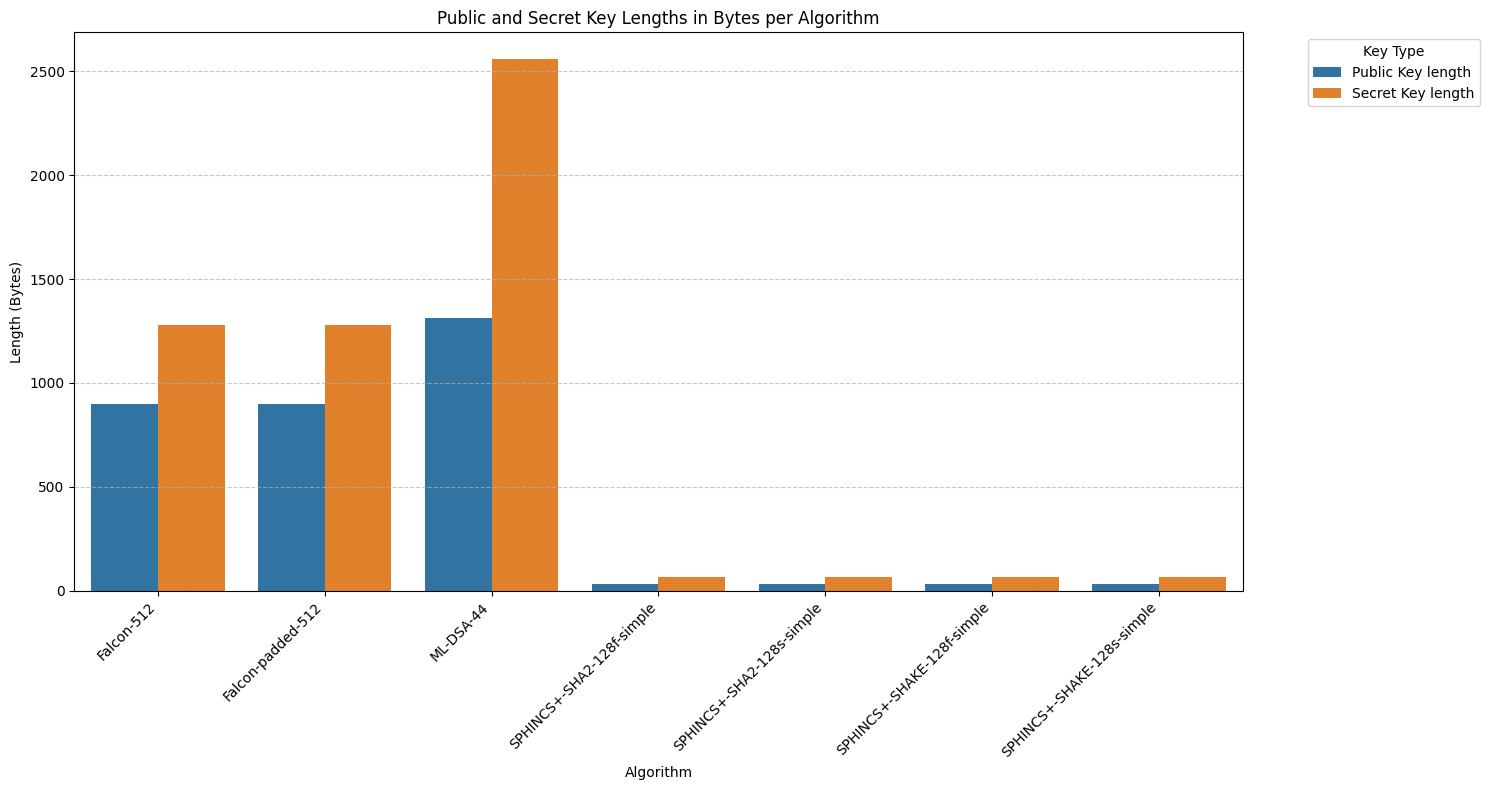

In [10]:
plot_key_length_comparison(df_keys_L1)

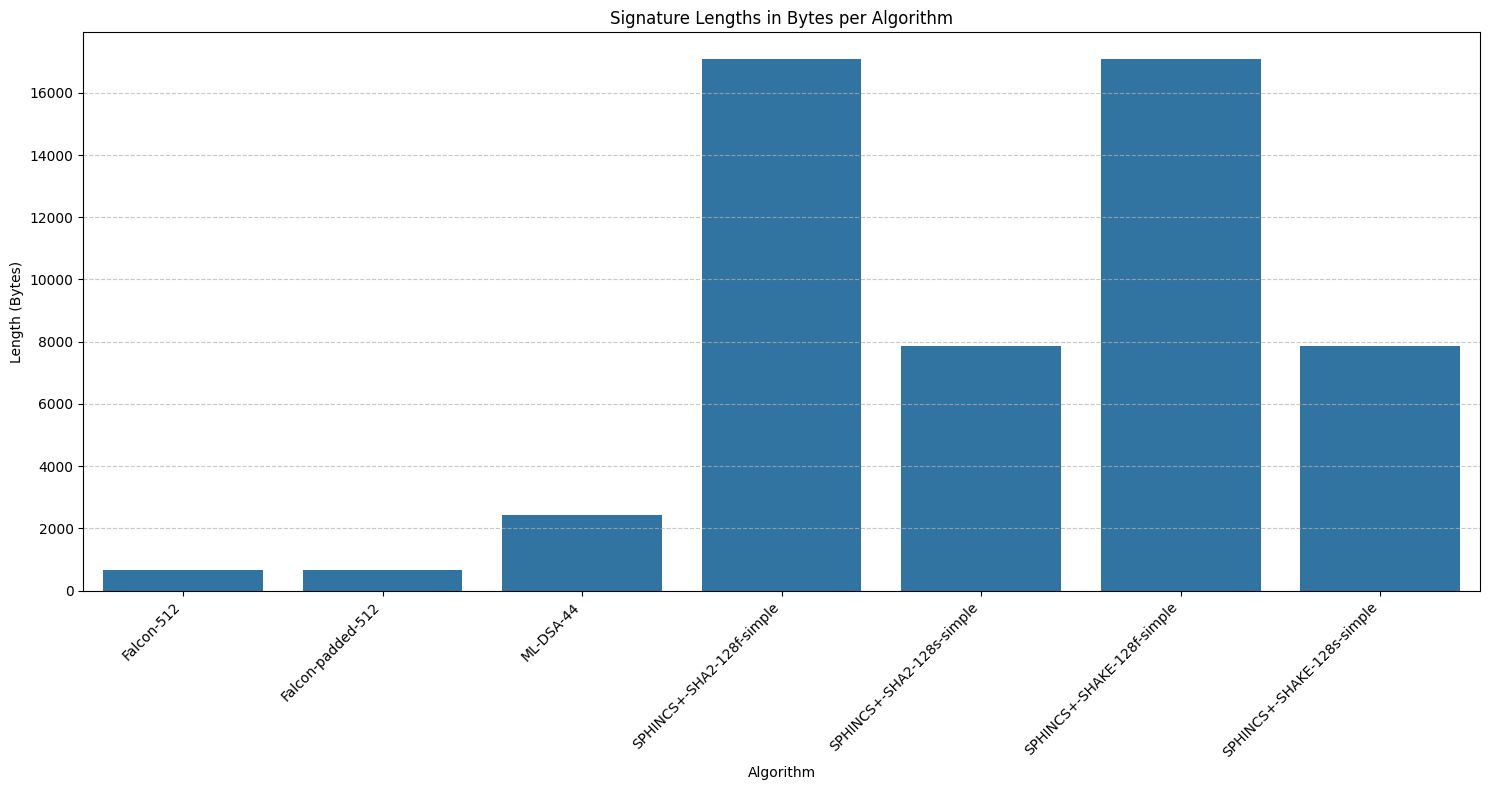

In [11]:
plot_key_length_comparison(df_signing_L1, "signature")


--- Plot: Key Generation Times ---


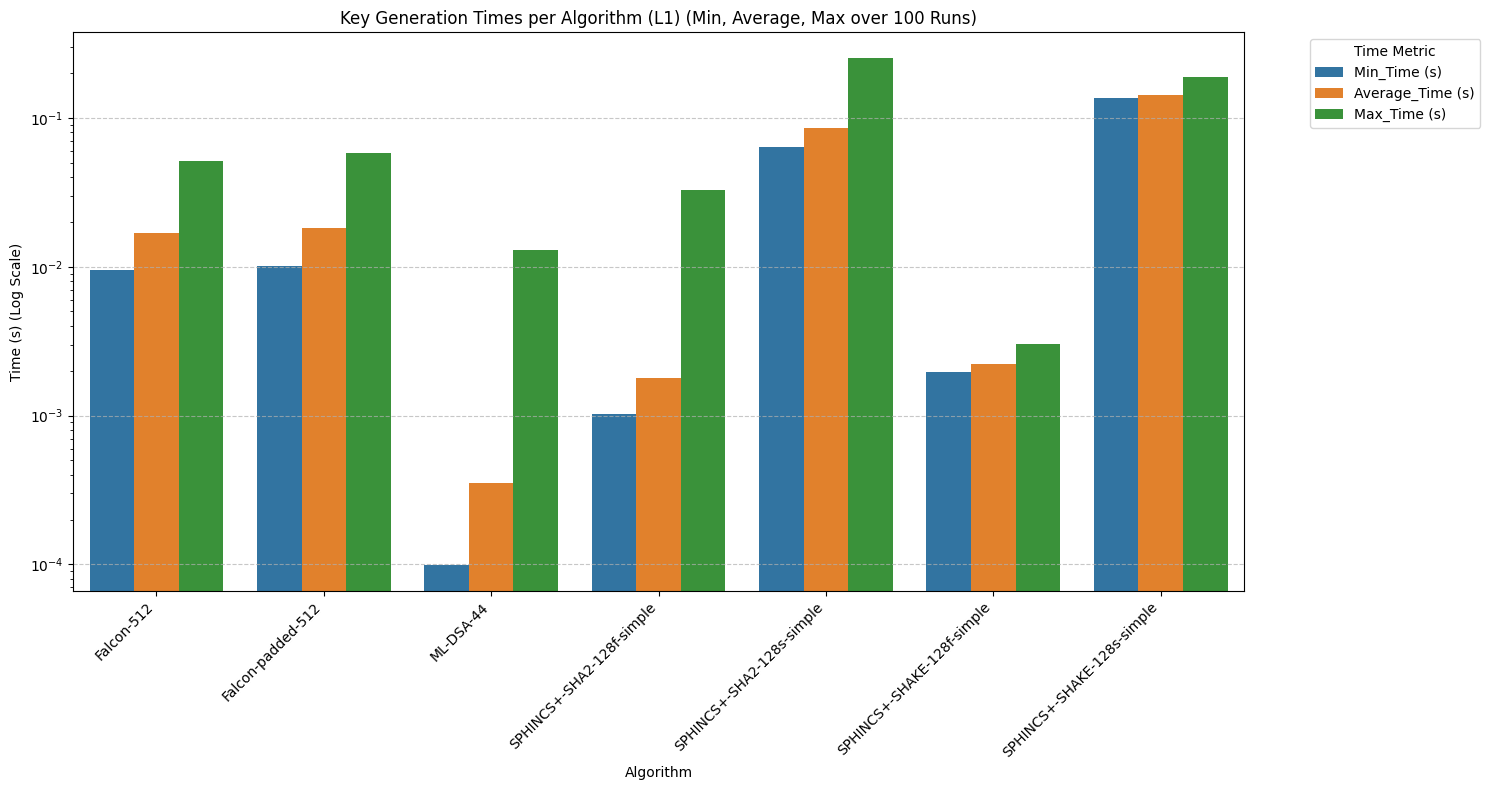

In [12]:
plot_timing_comparison(df_time_keys_L1, test_runs, "Key Generation", 1)


--- Plot: Signing Times ---


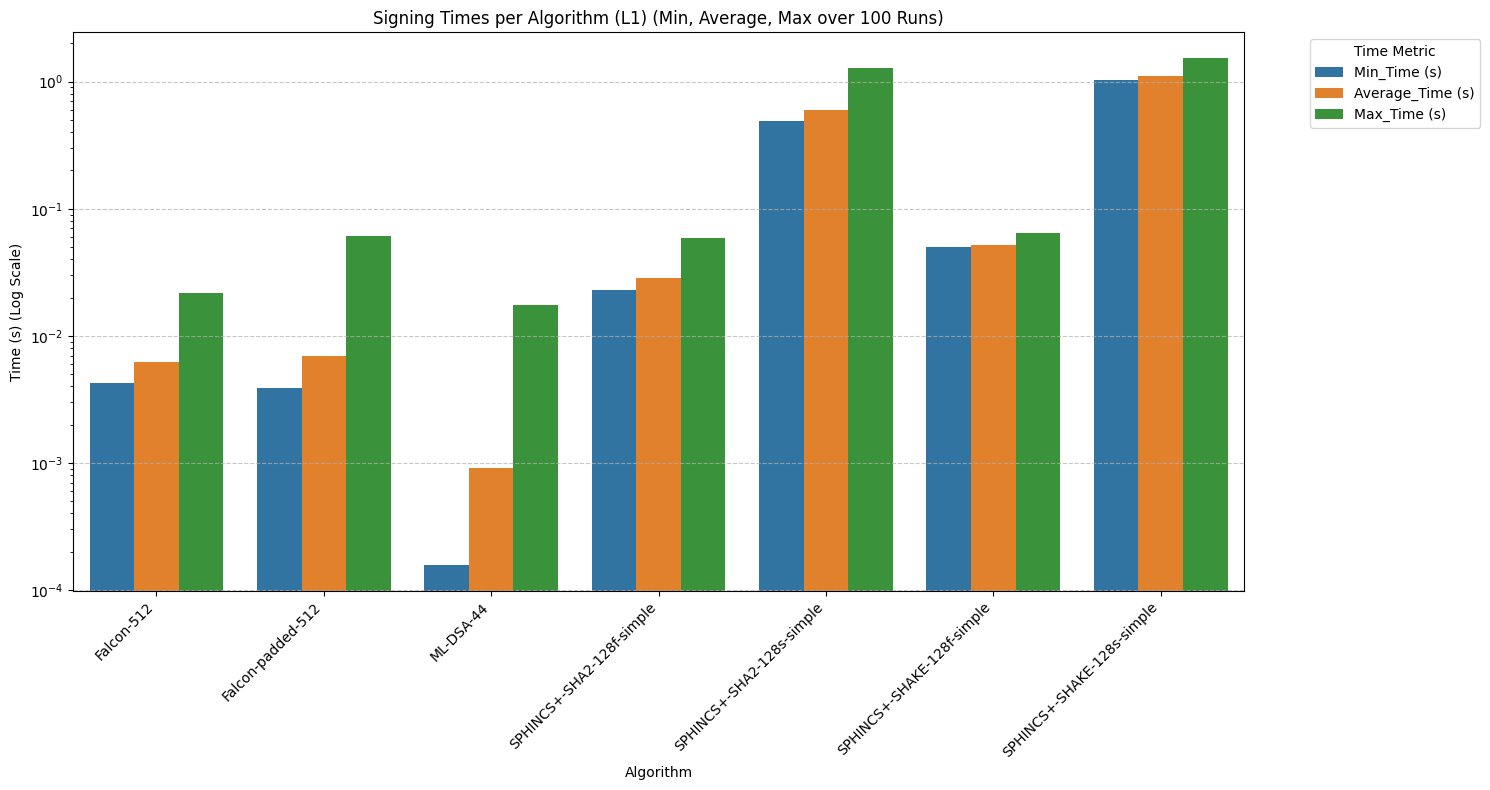

In [13]:
plot_timing_comparison(df_time_signing_L1, test_runs, "Signing", 1)


--- Plot: Verify Times ---


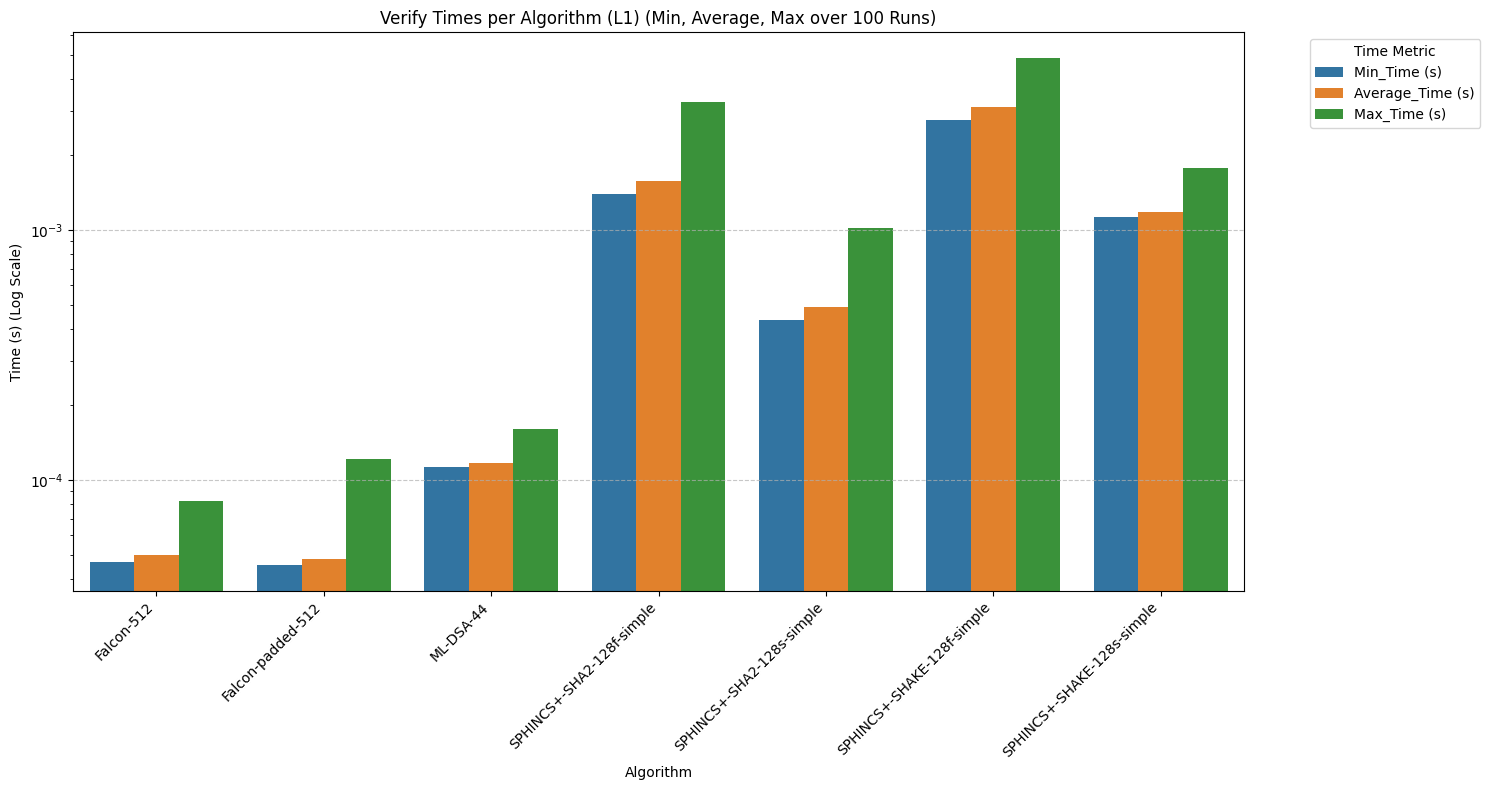

In [14]:
plot_timing_comparison(df_time_verify_L1, test_runs, "Verify", 1)

### Level 3 <a id="l3"></a>

In [15]:
print("\nLevel 3...")
df_keys_L3, df_time_keys_L3, df_signing_L3, df_time_signing_L3, df_verify_L3, df_time_verify_L3 = process_signing_level(signature_L3, test_runs, "L3")


Level 3...


In [16]:
display_results("L3", df_keys_L3, "Generated Keys")
display_results("L3", df_time_keys_L3, "Average Key Generation Times")


--- Generated Keys (L3) ---
                    Algorithm Security Level  \
0                   ML-DSA-65             L3   
1   SPHINCS+-SHA2-192f-simple             L3   
2   SPHINCS+-SHA2-192s-simple             L3   
3  SPHINCS+-SHAKE-192f-simple             L3   
4  SPHINCS+-SHAKE-192s-simple             L3   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [17]:
display_results("L3", df_signing_L3, "Signing Data")
display_results("L3", df_time_signing_L3, "Average Signing Times")


--- Signing Data (L3) ---
                    Algorithm Security Level              Message (plain)  \
0                   ML-DSA-65             L3  This is the message to sign   
1   SPHINCS+-SHA2-192f-simple             L3  This is the message to sign   
2   SPHINCS+-SHA2-192s-simple             L3  This is the message to sign   
3  SPHINCS+-SHAKE-192f-simple             L3  This is the message to sign   
4  SPHINCS+-SHAKE-192s-simple             L3  This is the message to sign   

   Message length  \
0              27   
1              27   
2              27   
3              27   
4              27   

                                                                                                                                                                                                                                                                                                                                                                                               

In [18]:
display_results("L3", df_verify_L3, "Verify Data")
display_results("L3", df_time_verify_L3, "Average Verify Times")


--- Verify Data (L3) ---
                    Algorithm Security Level  Is Valid
0                   ML-DSA-65             L3      True
1   SPHINCS+-SHA2-192f-simple             L3      True
2   SPHINCS+-SHA2-192s-simple             L3      True
3  SPHINCS+-SHAKE-192f-simple             L3      True
4  SPHINCS+-SHAKE-192s-simple             L3      True

--- Average Verify Times (L3) ---
                    Algorithm Security Level Operation  Min_Time (s)  \
0                   ML-DSA-65             L3    Verify      0.000151   
1   SPHINCS+-SHA2-192f-simple             L3    Verify      0.001902   
2   SPHINCS+-SHA2-192s-simple             L3    Verify      0.000753   
3  SPHINCS+-SHAKE-192f-simple             L3    Verify      0.004261   
4  SPHINCS+-SHAKE-192s-simple             L3    Verify      0.001498   

   Average_Time (s)  Max_Time (s)  
0          0.000170      0.000302  
1          0.002695      0.005237  
2          0.000838      0.001491  
3          0.004590      0.00855

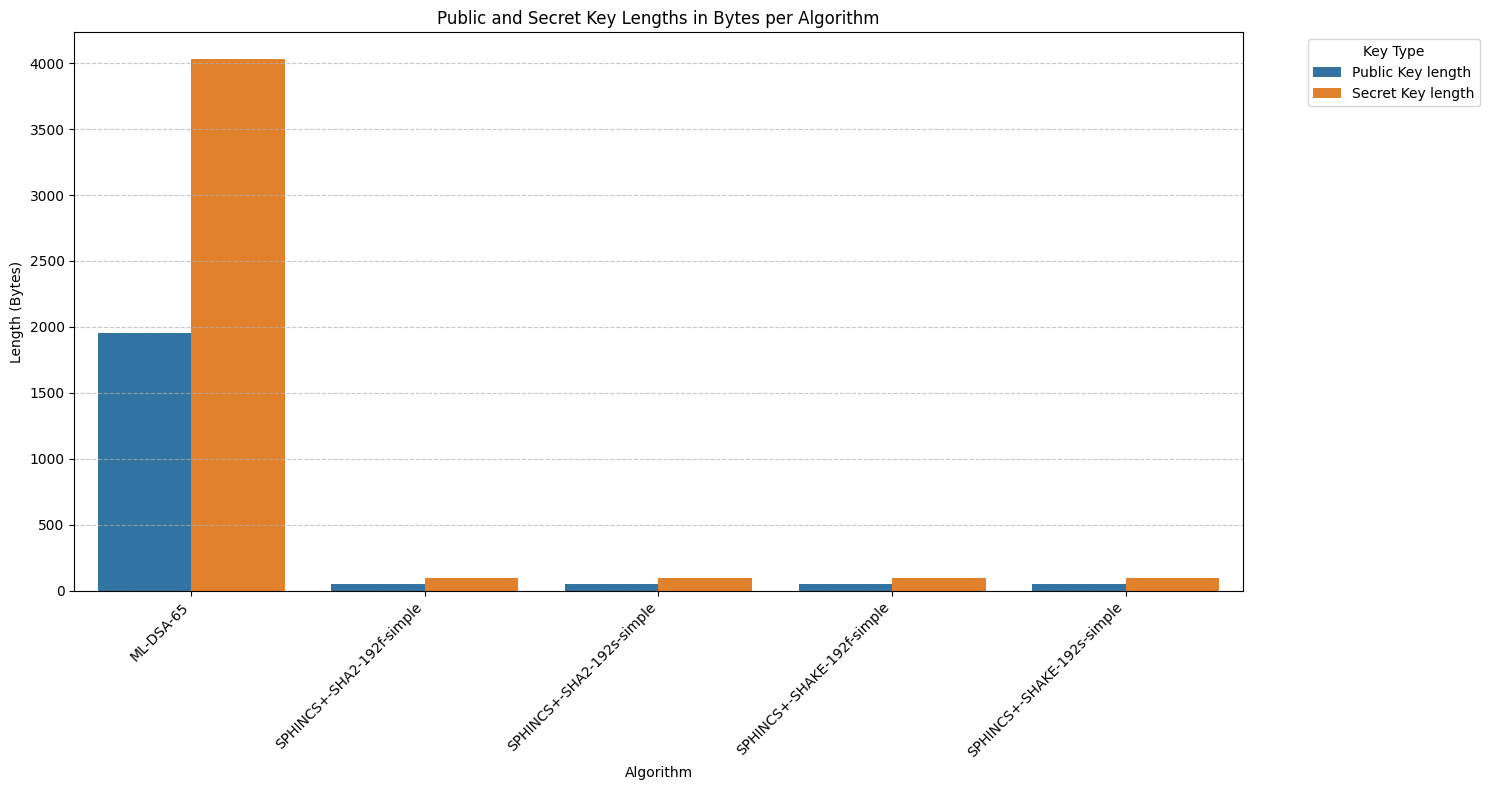

In [19]:
plot_key_length_comparison(df_keys_L3)

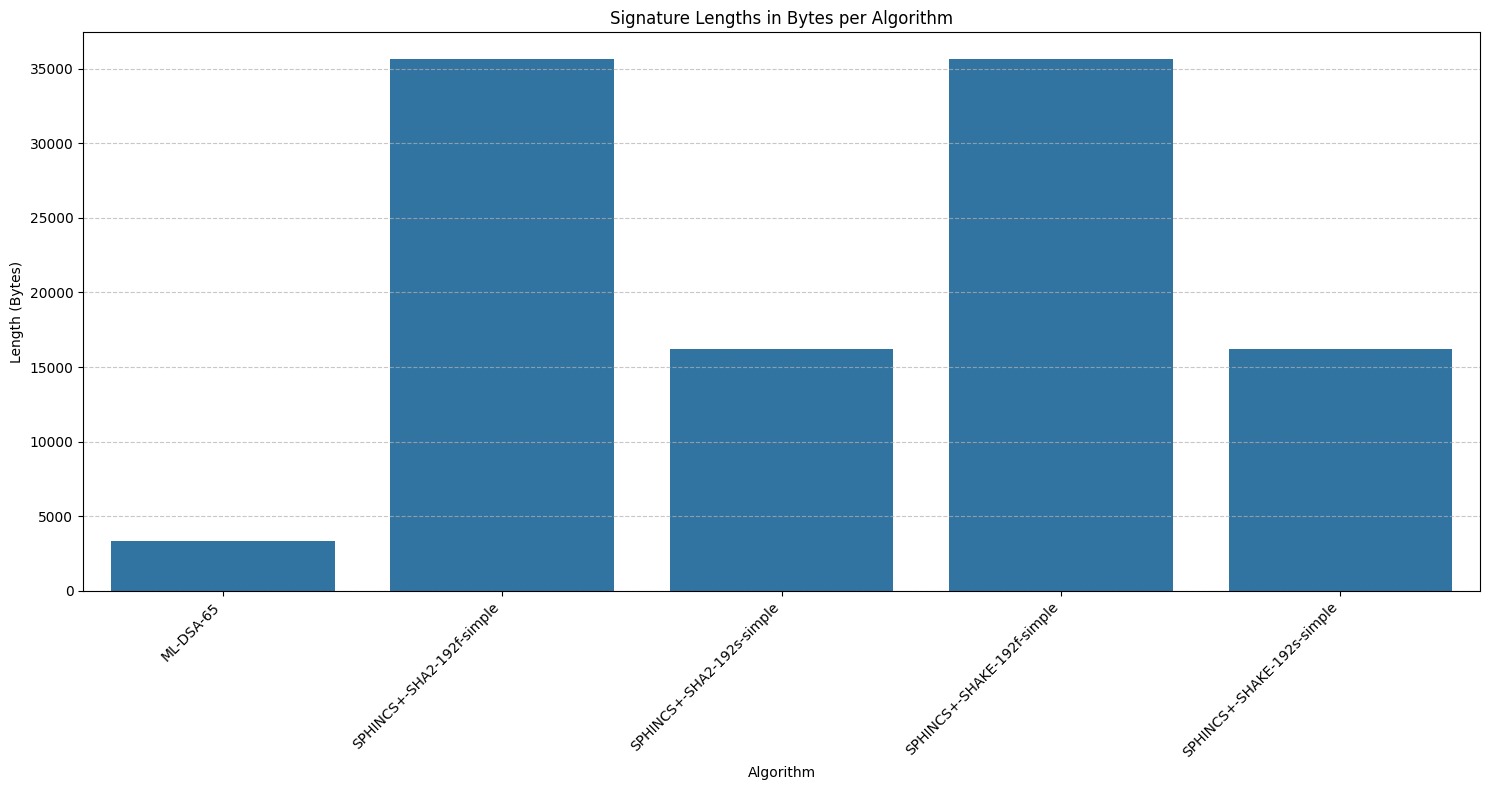

In [20]:
plot_key_length_comparison(df_signing_L3, "signature")


--- Plot: Key Generation Times ---


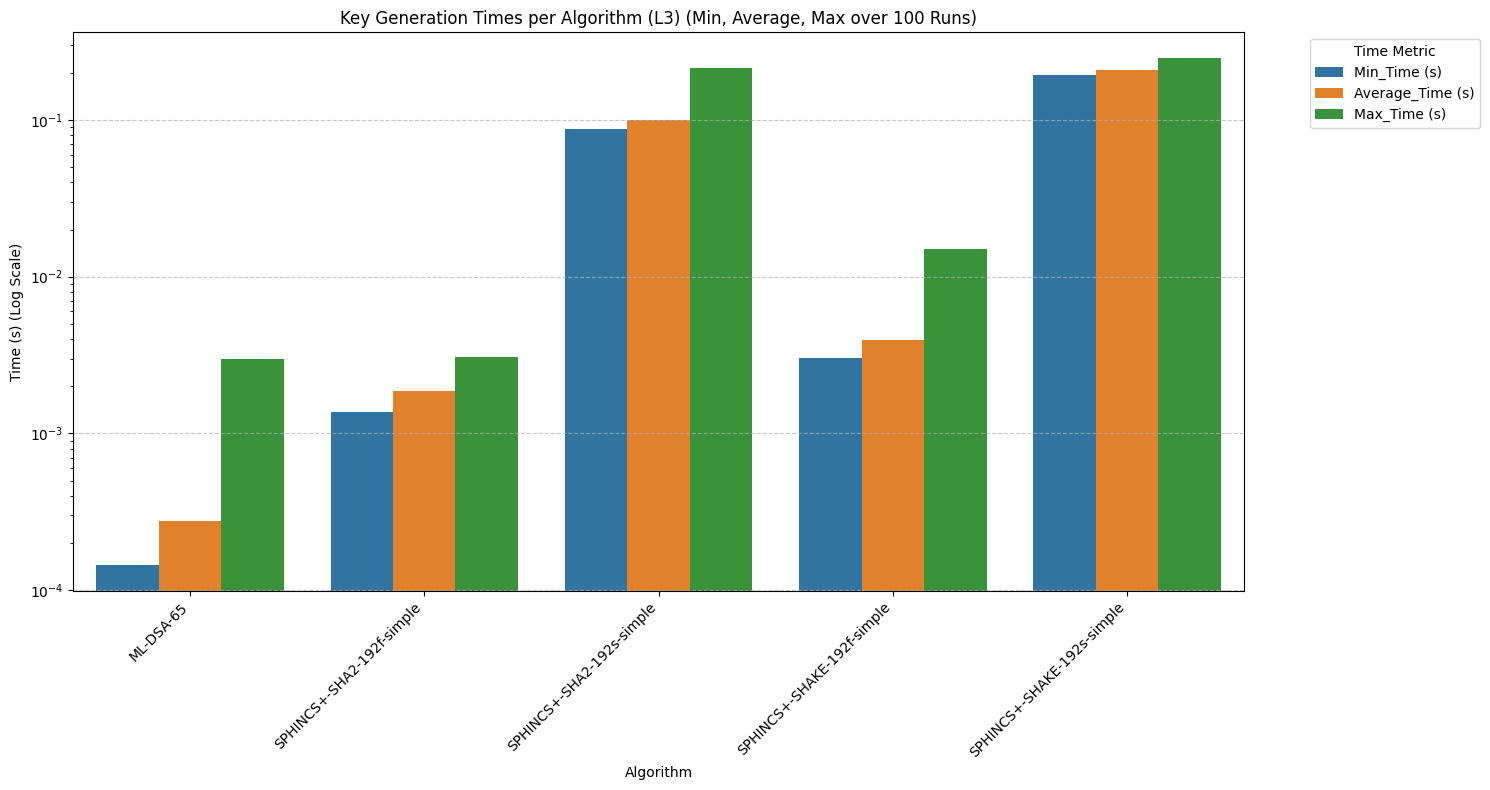

In [21]:
plot_timing_comparison(df_time_keys_L3, test_runs, "Key Generation", 3)


--- Plot: Signing Times ---


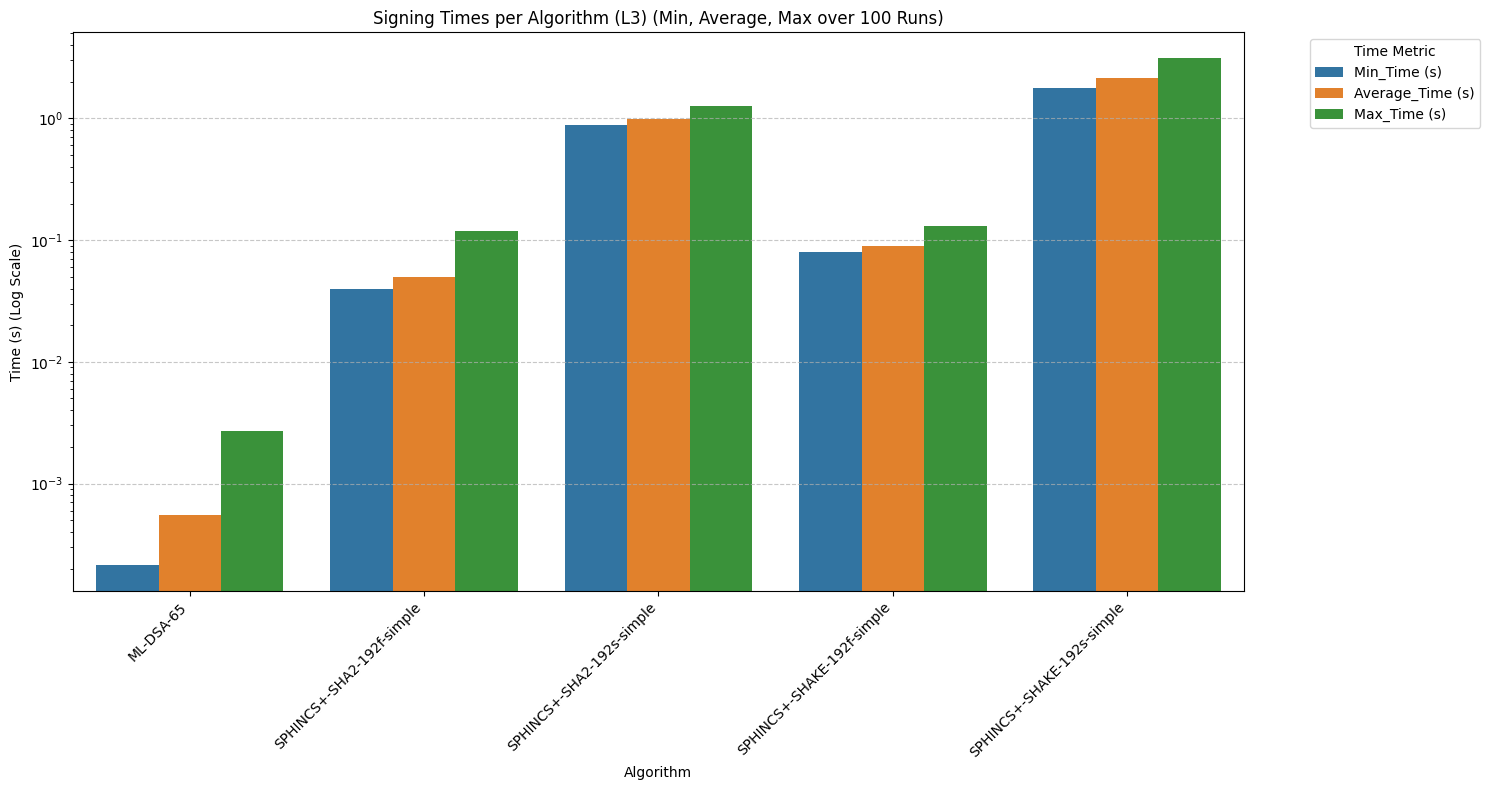

In [22]:
plot_timing_comparison(df_time_signing_L3, test_runs, "Signing", 3)


--- Plot: Verify Times ---


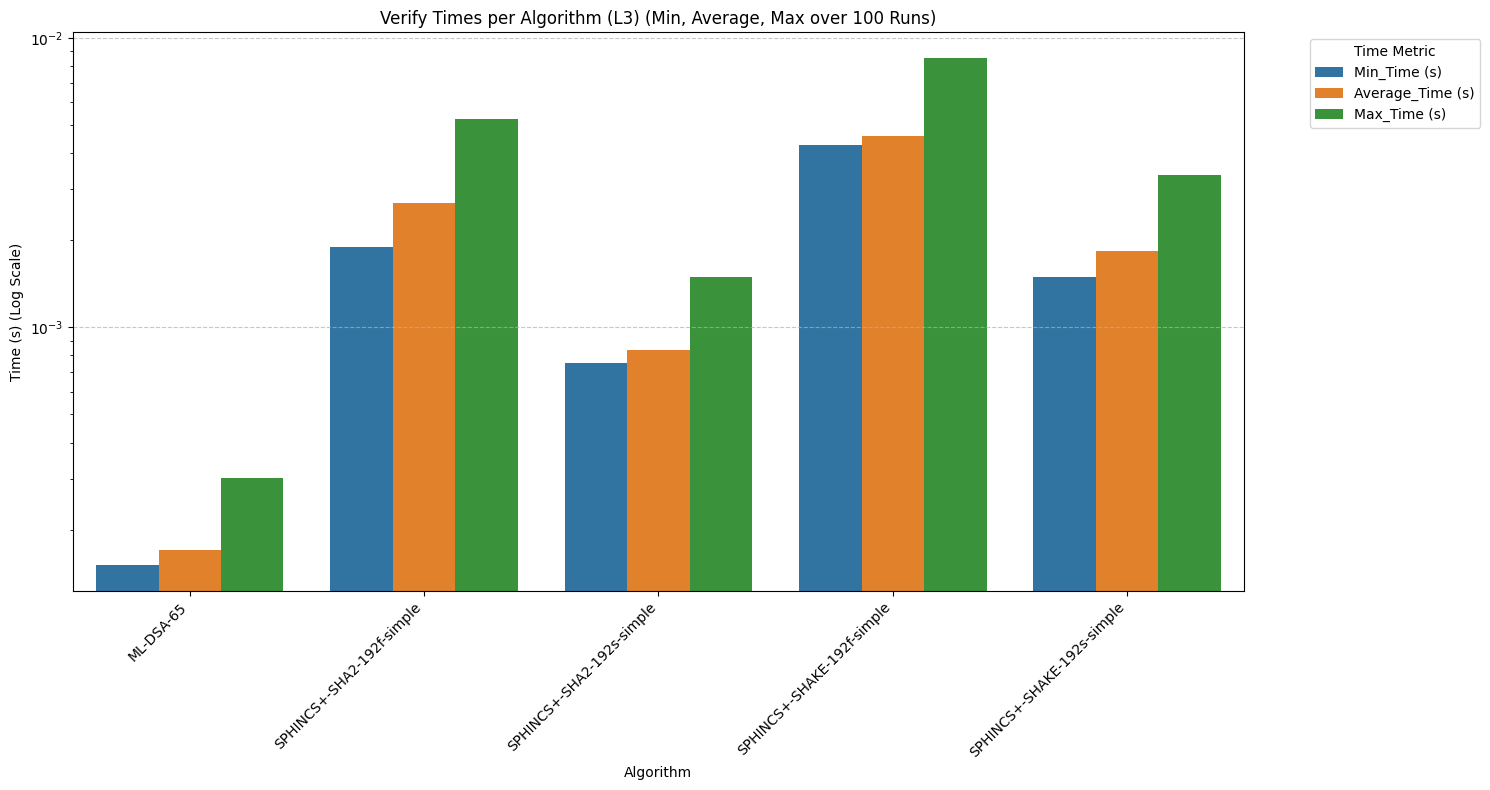

In [23]:
plot_timing_comparison(df_time_verify_L3, test_runs, "Verify", 3)

### Level 5 <a id="l5"></a>

In [24]:
print("\nLevel 5...")
df_keys_L5, df_time_keys_L5, df_signing_L5, df_time_signing_L5, df_verify_L5, df_time_verify_L5 = process_signing_level(signature_L5, test_runs, "L5")


Level 5...


In [25]:
display_results("L5", df_keys_L5, "Generated Keys")
display_results("L5", df_time_keys_L5, "Average Key Generation Times")


--- Generated Keys (L5) ---
                    Algorithm Security Level  \
0                   ML-DSA-87             L5   
1                 Falcon-1024             L5   
2          Falcon-padded-1024             L5   
3   SPHINCS+-SHA2-256f-simple             L5   
4   SPHINCS+-SHA2-256s-simple             L5   
5  SPHINCS+-SHAKE-256f-simple             L5   
6  SPHINCS+-SHAKE-256s-simple             L5   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [26]:
display_results("L5", df_signing_L5, "Signing Data")
display_results("L5", df_time_signing_L5, "Average Signing Times")


--- Signing Data (L5) ---
                    Algorithm Security Level              Message (plain)  \
0                   ML-DSA-87             L5  This is the message to sign   
1                 Falcon-1024             L5  This is the message to sign   
2          Falcon-padded-1024             L5  This is the message to sign   
3   SPHINCS+-SHA2-256f-simple             L5  This is the message to sign   
4   SPHINCS+-SHA2-256s-simple             L5  This is the message to sign   
5  SPHINCS+-SHAKE-256f-simple             L5  This is the message to sign   
6  SPHINCS+-SHAKE-256s-simple             L5  This is the message to sign   

   Message length  \
0              27   
1              27   
2              27   
3              27   
4              27   
5              27   
6              27   

                                                                                                                                                                                           

In [27]:
display_results("L5", df_verify_L5, "Verify Data")
display_results("L5", df_time_verify_L5, "Average Verify Times")


--- Verify Data (L5) ---
                    Algorithm Security Level  Is Valid
0                   ML-DSA-87             L5      True
1                 Falcon-1024             L5      True
2          Falcon-padded-1024             L5      True
3   SPHINCS+-SHA2-256f-simple             L5      True
4   SPHINCS+-SHA2-256s-simple             L5      True
5  SPHINCS+-SHAKE-256f-simple             L5      True
6  SPHINCS+-SHAKE-256s-simple             L5      True

--- Average Verify Times (L5) ---
                    Algorithm Security Level Operation  Min_Time (s)  \
0                   ML-DSA-87             L5    Verify      0.000250   
1                 Falcon-1024             L5    Verify      0.000075   
2          Falcon-padded-1024             L5    Verify      0.000108   
3   SPHINCS+-SHA2-256f-simple             L5    Verify      0.002122   
4   SPHINCS+-SHA2-256s-simple             L5    Verify      0.001039   
5  SPHINCS+-SHAKE-256f-simple             L5    Verify      0.00430

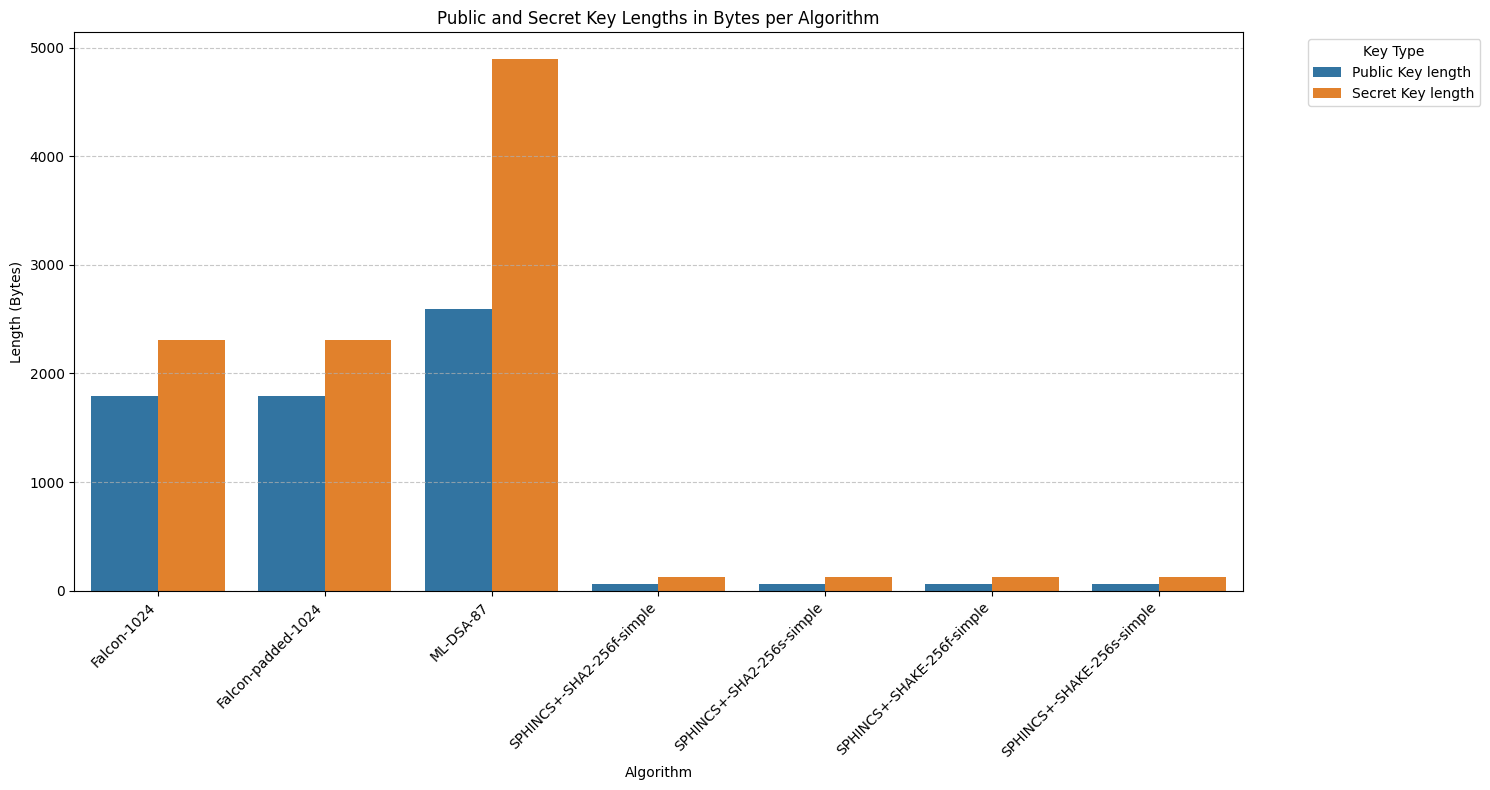

In [28]:
plot_key_length_comparison(df_keys_L5)

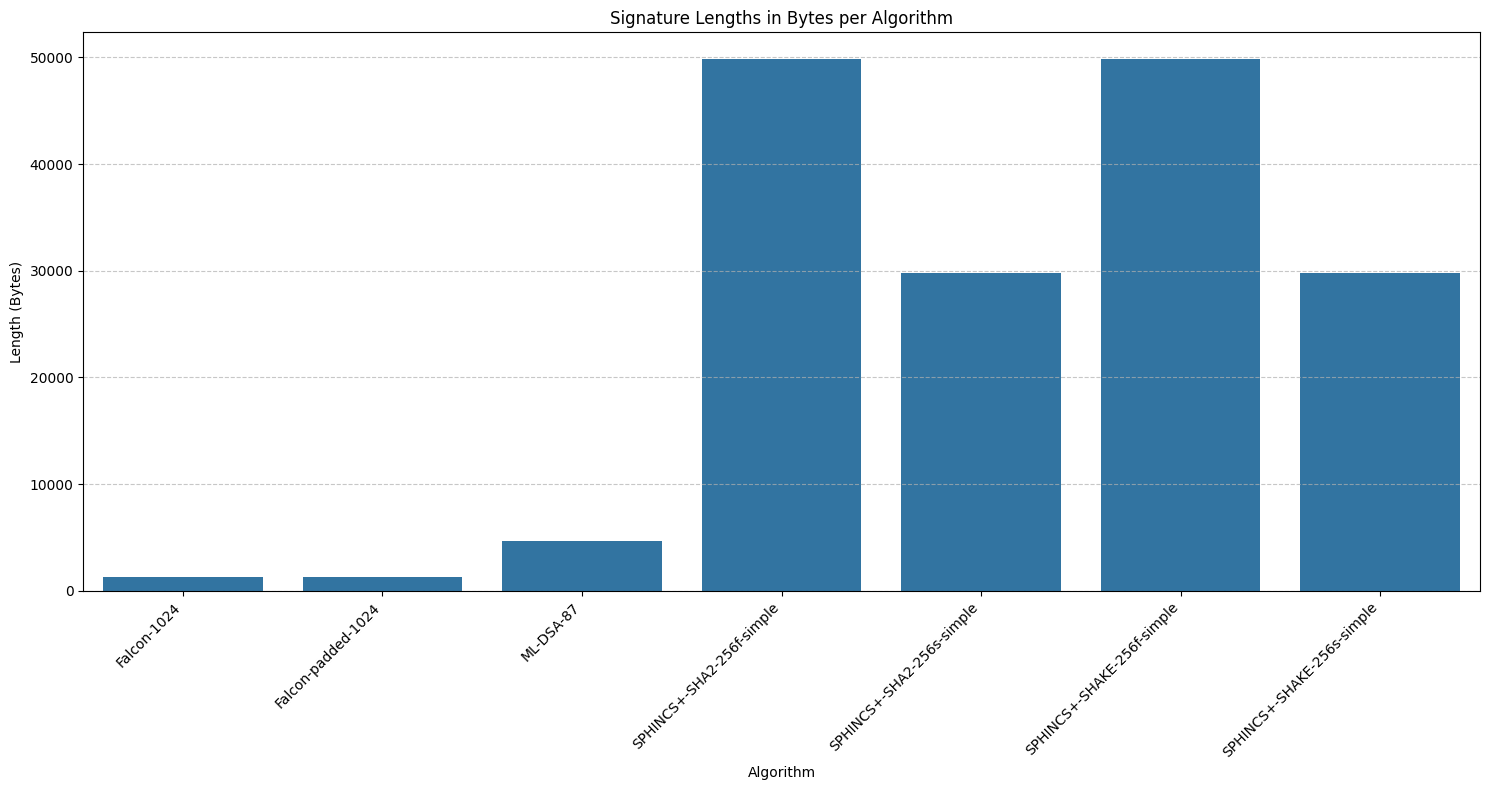

In [29]:
plot_key_length_comparison(df_signing_L5, "signature")


--- Plot: Key Generation Times ---


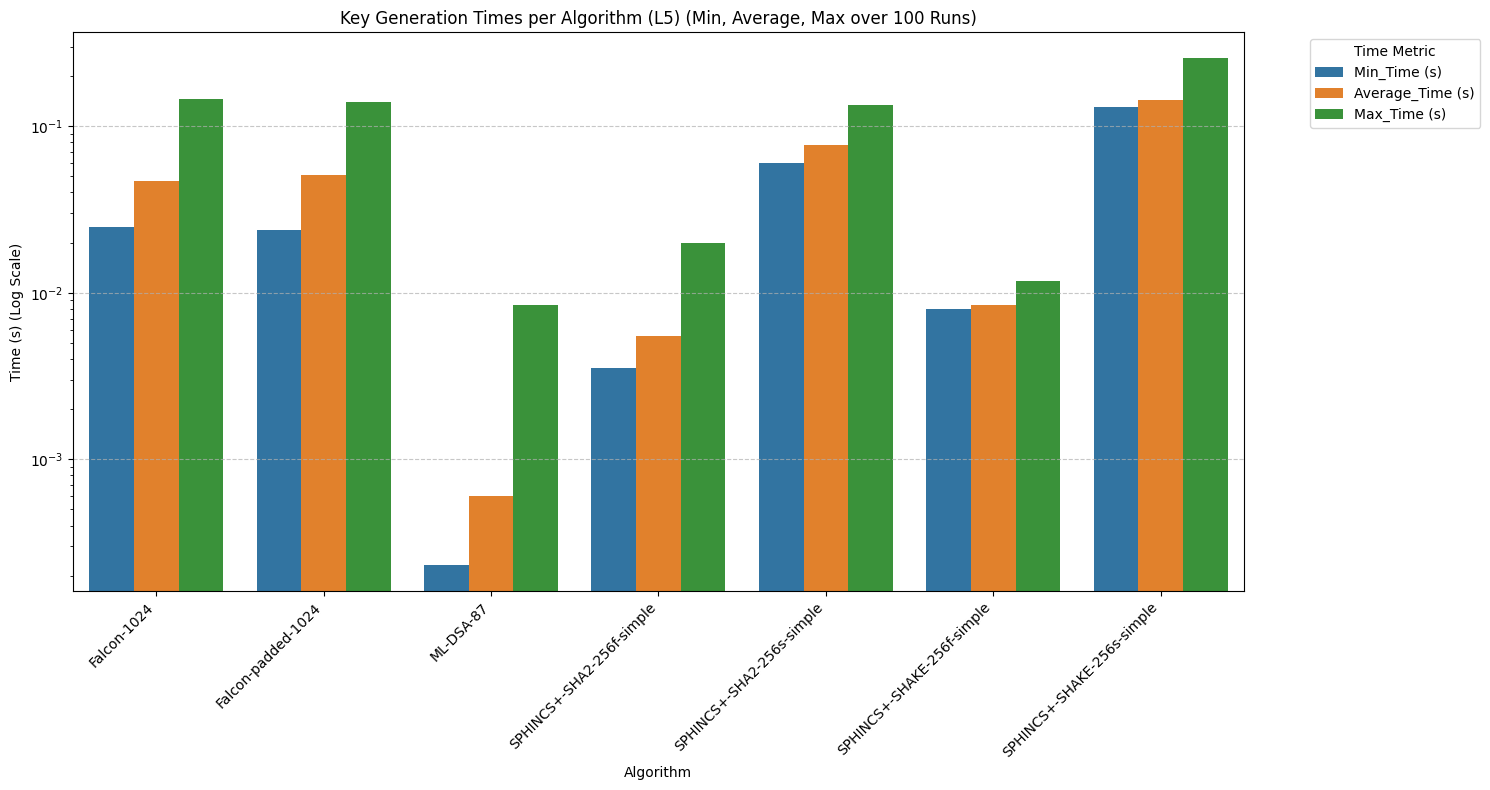

In [30]:
plot_timing_comparison(df_time_keys_L5, test_runs, "Key Generation", 5)


--- Plot: Signing Times ---


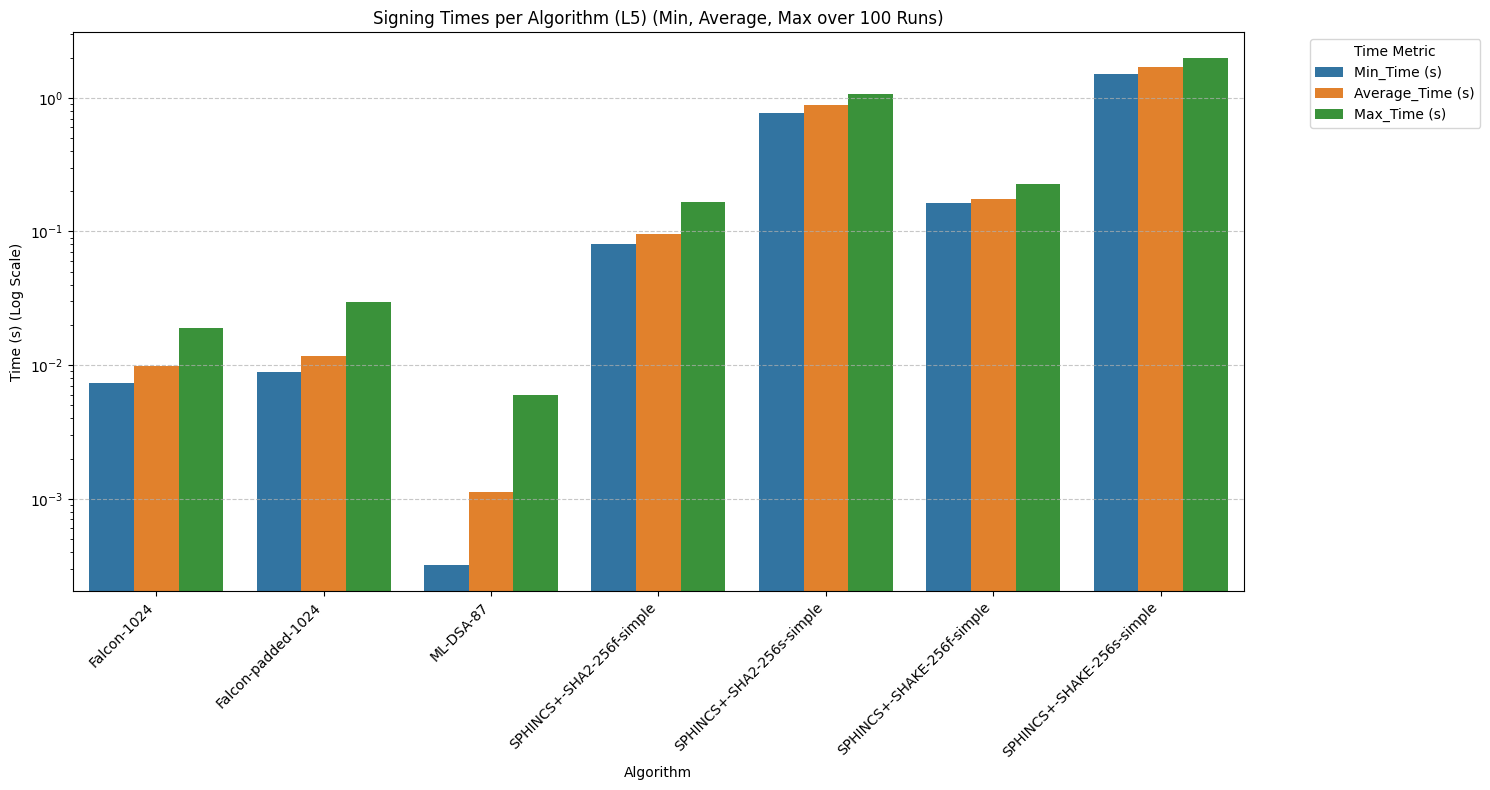

In [31]:
plot_timing_comparison(df_time_signing_L5, test_runs, "Signing", 5)


--- Plot: Verify Times ---


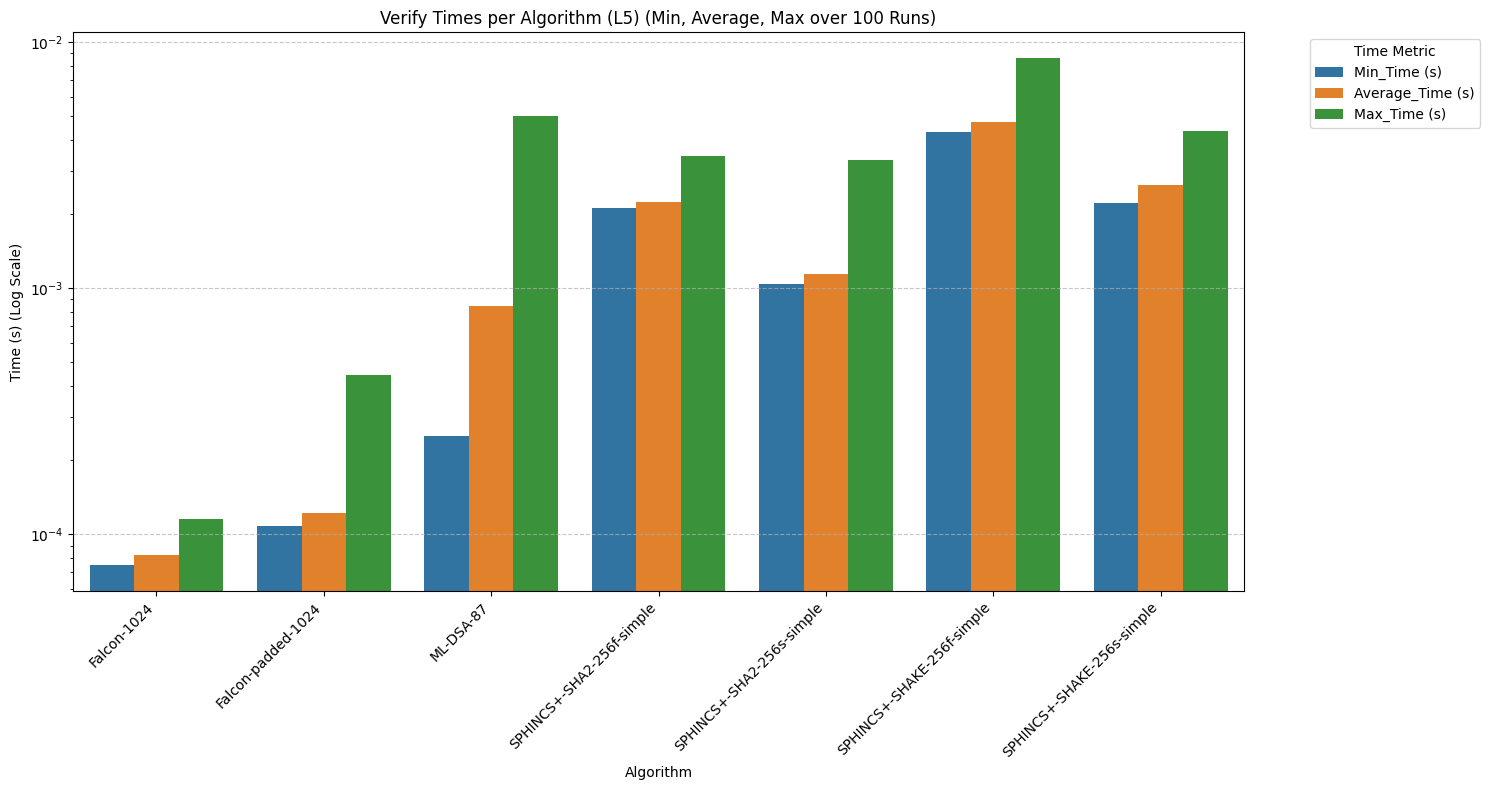

In [32]:
plot_timing_comparison(df_time_verify_L5, test_runs, "Verify", 5)

## Conclusion <a id="conclusion"></a>

All algorithms show extremely **diverse performance** values for key generation, signing, and verification. To gain a comprehensive overview of the time taken, we will therefore sum the individual operation times for each algorithm.

Unlike KEMs (Key Encapsulation Mechanisms), where one algorithm might consistently outperform others across all operations, the choice of algorithm here is highly dependent on **specific requirements**. There's no single "best" algorithm; instead, the optimal choice will be dictated by which operations are most critical for the particular application.


--- Plot: Total Times ---


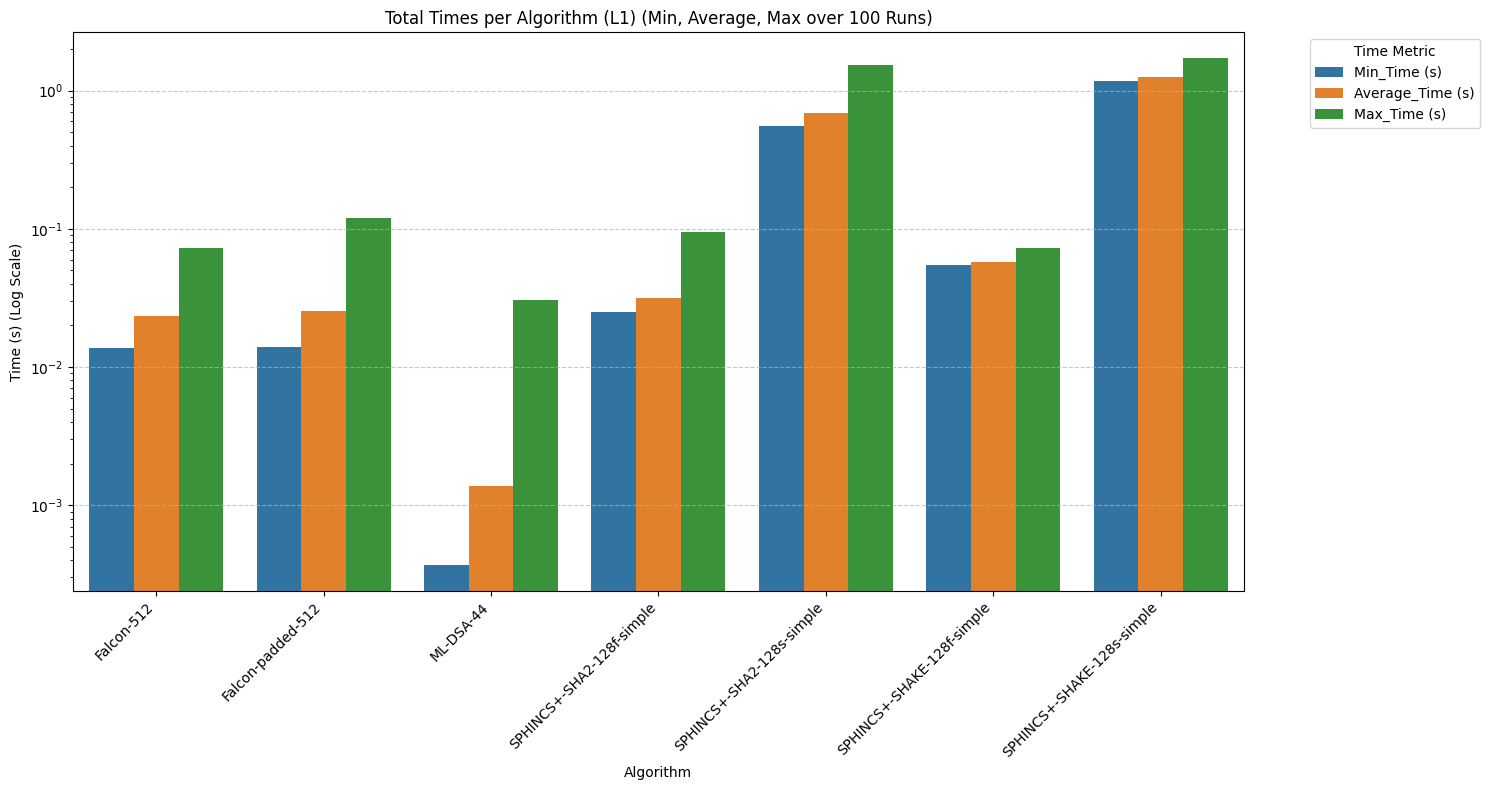

In [33]:
all_dfs_L1 = [df_time_keys_L1, df_time_signing_L1, df_time_verify_L1]
total_times_L1 = pd.concat(all_dfs_L1, ignore_index=True).groupby(['Algorithm', 'Security Level'])[
    ['Min_Time (s)', 'Average_Time (s)', 'Max_Time (s)']].sum().reset_index()
plot_timing_comparison(total_times_L1, test_runs, "Total", 1)


--- Plot: Total Times ---


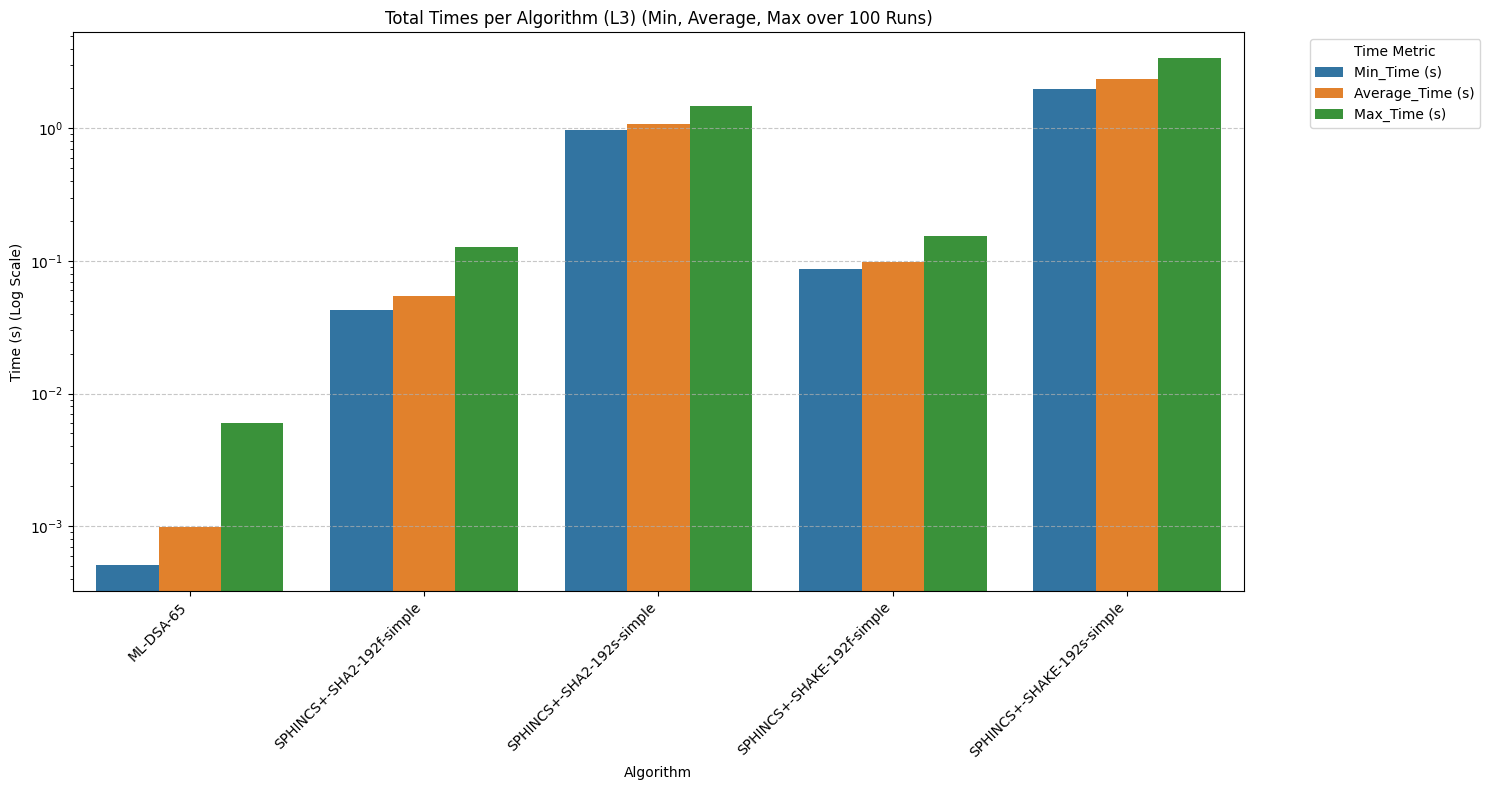

In [34]:
all_dfs_L3 = [df_time_keys_L3, df_time_signing_L3, df_time_verify_L3]
total_times_L3 = pd.concat(all_dfs_L3, ignore_index=True).groupby(['Algorithm', 'Security Level'])[
    ['Min_Time (s)', 'Average_Time (s)', 'Max_Time (s)']].sum().reset_index()
plot_timing_comparison(total_times_L3, test_runs, "Total", 3)


--- Plot: Total Times ---


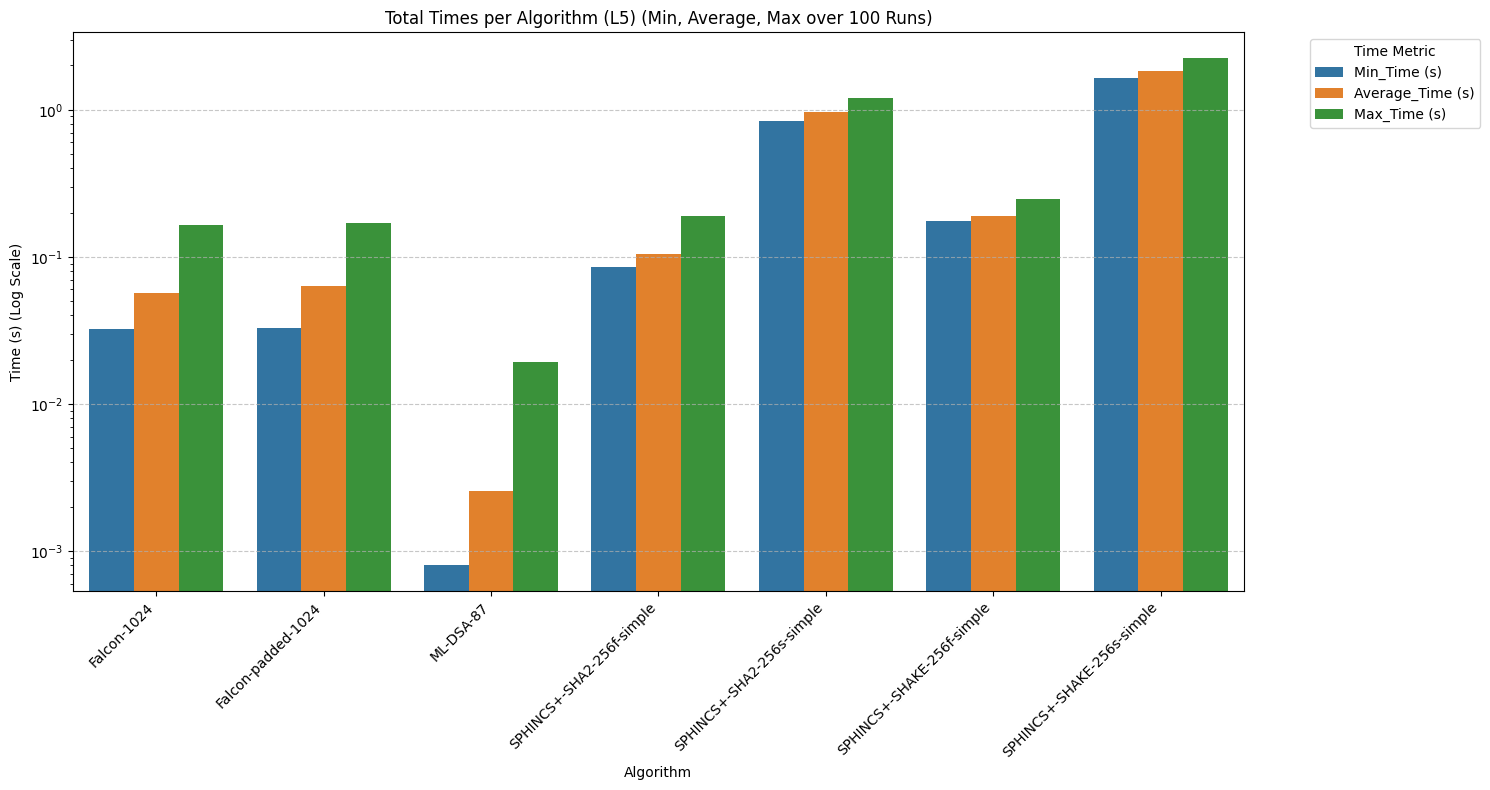

In [35]:
all_dfs_L5 = [df_time_keys_L5, df_time_signing_L5, df_time_verify_L5]
total_times_L5 = pd.concat(all_dfs_L5, ignore_index=True).groupby(['Algorithm', 'Security Level'])[
    ['Min_Time (s)', 'Average_Time (s)', 'Max_Time (s)']].sum().reset_index()
plot_timing_comparison(total_times_L5, test_runs, "Total", 5)

You'll notice that **ML-DSA** consistently achieves shorter total times across all security leveel, but utilizes the largest key sizes. In contrast, **SPHINCS+** records the longest execution times, although it benefits from having the smallest key sizes. **Falcon's** performance generally falls into the average range for both total time and key size.